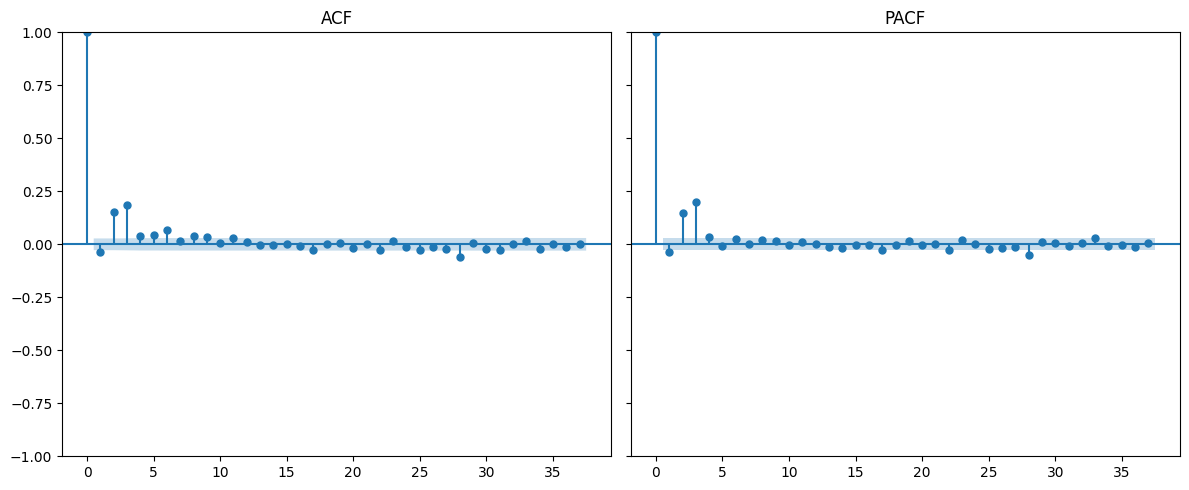

AR parameters: [0.081 0.112 0.178]
MA parameters: [-0.14   0.084]


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Parameters
p = 3  # AR order
q = 2  # MA order
n = 5000

# Randomly sample coefficients
# runif(p, min, max) equivalent is np.random.uniform(min, max, size)
theta = np.random.uniform(-1/p, 1/p, p)
phi = np.random.uniform(-1/q, 1/q, q)

# statsmodels requires the AR component to include the zero-lag (1) 
# and the signs of the lags to be negated.
ar_params = np.r_[1, -theta] 
ma_params = np.r_[1, phi]

# Create the process and simulate
arma_process = ArmaProcess(ar_params, ma_params)
Y = arma_process.generate_sample(nsample=n)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

plot_acf(Y, ax=axes[0], title="ACF")
plot_pacf(Y, ax=axes[1], title="PACF")

# plt.ylim(-0.25,0.25)
plt.tight_layout()
plt.show()

# Output parameters
print(f"AR parameters: {np.round(theta, 3)}")
print(f"MA parameters: {np.round(phi, 3)}")